## EXERCISE 1: GRADIENT DESCENT

1. Function gradient_descent

In [27]:
import numpy as np
import matplotlib.pyplot as plt

2. Gradient Descent Function

In [28]:
def gradient_descent(f, df, x_init, lr=0.1, steps=10):
    x_vals = [x_init]
    x = x_init

    print(f"{'Step':<5} {'x':>10} {'f(x)':>15}")
    print('-' * 30)

    for i in range(steps):
        fx = f(x)
        print(f"{i:<5} {x:>10.5f} {fx:>15.5f}")
        x = x - lr * df(x)
        x_vals.append(x)

    fx = f(x)
    print(f"{steps:<5} {x:>10.5f} {fx:>15.5f}")
    return x_vals

3. Plot function

In [29]:
def plot_descent(f, df, x_init, lr, steps, title, xlim=(-10, 10), ylim=None):
    x_vals = gradient_descent(f, df, x_init, lr, steps)
    x_range = np.linspace(xlim[0], xlim[1], 1000)
    y_range = f(x_range)

    plt.figure(figsize=(10, 6))
    plt.plot(x_range, y_range, label='Function', color='blue')
    plt.scatter(x_vals, [f(x) for x in x_vals], color='red', label='Descent Steps')

    for i in range(len(x_vals) - 1):
        plt.arrow(
            x_vals[i], f(x_vals[i]),
            x_vals[i + 1] - x_vals[i],
            f(x_vals[i + 1]) - f(x_vals[i]),
            head_width=0.3, color='green', length_includes_head=True
        )

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.legend()
    plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.show()

4. Test Functions

In [30]:
f1 = lambda x: x**2
df1 = lambda x: 2*x

f2 = lambda x: x**3
df2 = lambda x: 3*x**2

f3 = lambda x: x**4 - 3*x**3 + 2
df3 = lambda x: 4*x**3 - 9*x**2

5. Call the plotting function to observe the results

Step           x            f(x)
------------------------------
0        8.00000        64.00000
1        3.20000        10.24000
2        1.28000         1.63840
3        0.51200         0.26214
4        0.20480         0.04194
5        0.08192         0.00671
6        0.03277         0.00107
7        0.01311         0.00017
8        0.00524         0.00003
9        0.00210         0.00000
10       0.00084         0.00000


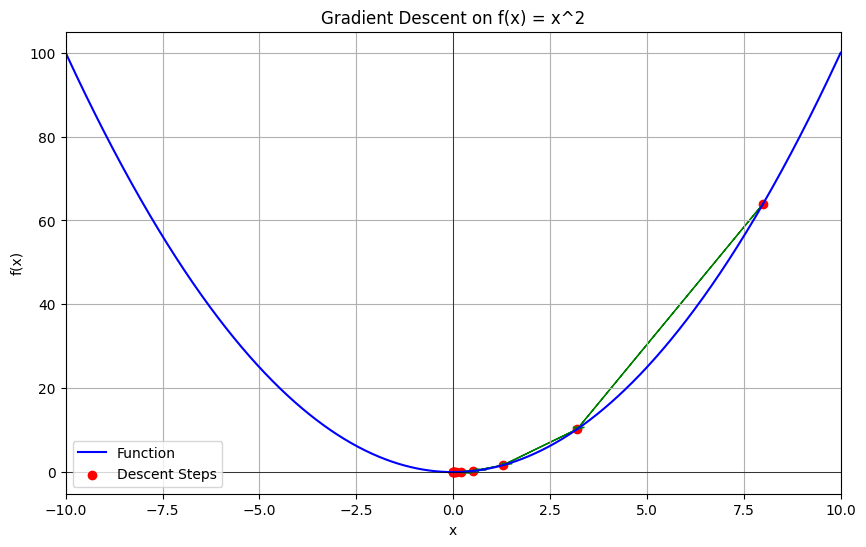

Step           x            f(x)
------------------------------
0        2.00000         8.00000
1        1.88000         6.64467
2        1.77397         5.58261
3        1.67956         4.73790
4        1.59493         4.05720
5        1.51862         3.50223
6        1.44943         3.04504
7        1.38641         2.66484
8        1.32874         2.34597
9        1.27578         2.07646
10       1.22695         1.84705
11       1.18179         1.65050
12       1.13989         1.48110
13       1.10091         1.33429
14       1.06455         1.20641
15       1.03055         1.09448
16       0.99869         0.99607
17       0.96877         0.90920
18       0.94061         0.83221
19       0.91407         0.76372
20       0.88900         0.70260
21       0.86529         0.64787
22       0.84283         0.59872
23       0.82152         0.55444
24       0.80127         0.51445
25       0.78201         0.47823
26       0.76367         0.44536
27       0.74617         0.41545
28       0.7

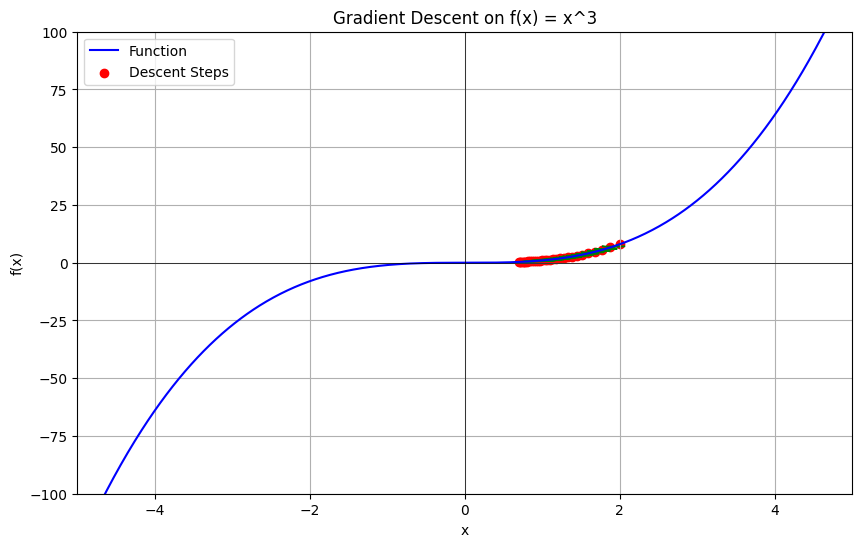

Step           x            f(x)
------------------------------
0        0.00000         2.00000
1        0.00000         2.00000
2        0.00000         2.00000
3        0.00000         2.00000
4        0.00000         2.00000
5        0.00000         2.00000
6        0.00000         2.00000
7        0.00000         2.00000
8        0.00000         2.00000
9        0.00000         2.00000
10       0.00000         2.00000
11       0.00000         2.00000
12       0.00000         2.00000
13       0.00000         2.00000
14       0.00000         2.00000
15       0.00000         2.00000
16       0.00000         2.00000
17       0.00000         2.00000
18       0.00000         2.00000
19       0.00000         2.00000
20       0.00000         2.00000
21       0.00000         2.00000
22       0.00000         2.00000
23       0.00000         2.00000
24       0.00000         2.00000
25       0.00000         2.00000
26       0.00000         2.00000
27       0.00000         2.00000
28       0.0

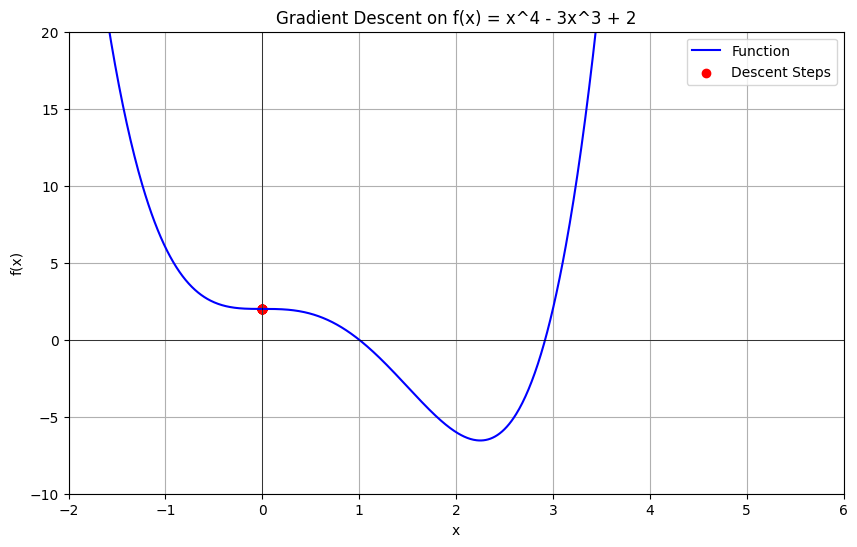

In [31]:
plot_descent(f1, df1, x_init=8, lr=0.3, steps=10, title='Gradient Descent on f(x) = x^2', xlim=(-10, 10))
plot_descent(f2, df2, x_init=2, lr=0.01, steps=30, title='Gradient Descent on f(x) = x^3', xlim=(-5, 5), ylim=(-100, 100))
plot_descent(f3, df3, x_init=0, lr=0.01, steps=30, title='Gradient Descent on f(x) = x^4 - 3x^3 + 2', xlim=(-2, 6), ylim=(-10, 20))

6. Experiment with regression problem

Add necessary libraries

In [32]:
import numpy as np
import matplotlib.pyplot as plt

Create synthetic data (the true value of w is 3)

In [33]:
np.random.seed(0)
x_data = np.linspace(0, 10, 20)
y_data = 3.0 * x_data + np.random.randn(*x_data.shape) * 3  # true w = 3.0

Initialize weight, learning rate, and number of steps

In [34]:
w = 0.0
lr = 0.001
steps = 50

Create variables to store weight values and loss after each update

In [35]:
w_history = []
loss_history = []

Visualization of results

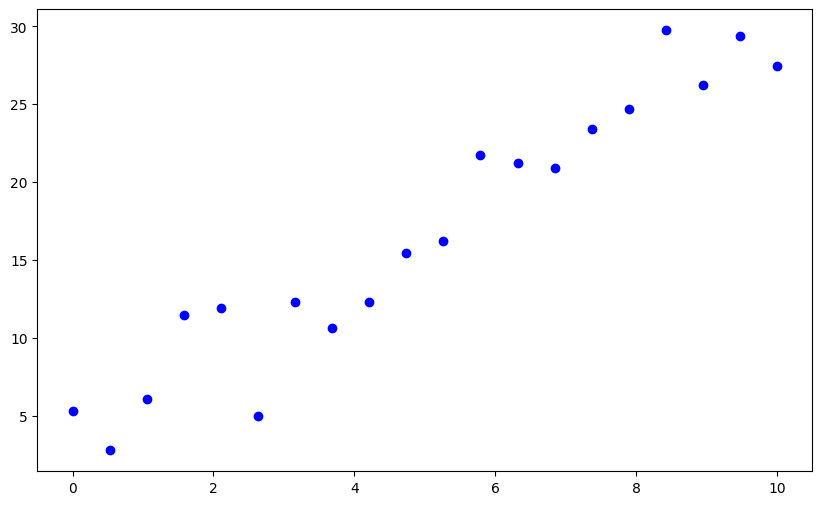

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label='Data', color='blue')

Run the algorithm

Step         w         Loss       grad
-----------------------------------
0       0.0000     349.7034  -216.0585
1       0.2161     304.6191  -201.2756
2       0.4173     265.4932  -187.5041
3       0.6048     231.5382  -174.6749
4       0.7795     202.0707  -162.7234
5       0.9422     176.4976  -151.5897
6       1.0938     154.3043  -141.2178
7       1.2350     135.0441  -131.5555
8       1.3666     118.3293  -122.5544
9       1.4892     103.8236  -114.1691
10      1.6033      91.2349  -106.3575
11      1.7097      80.3100   -99.0804
12      1.8088      70.8289   -92.3012
13      1.9011      62.6009   -85.9859
14      1.9870      55.4602   -80.1026
15      2.0672      49.2633   -74.6219
16      2.1418      43.8854   -69.5162
17      2.2113      39.2182   -64.7598
18      2.2760      35.1678   -60.3289
19      2.3364      31.6528   -56.2011
20      2.3926      28.6023   -52.3558
21      2.4449      25.9549   -48.7736
22      2.4937      23.6574   -45.4364
23      2.5391      21.6636 

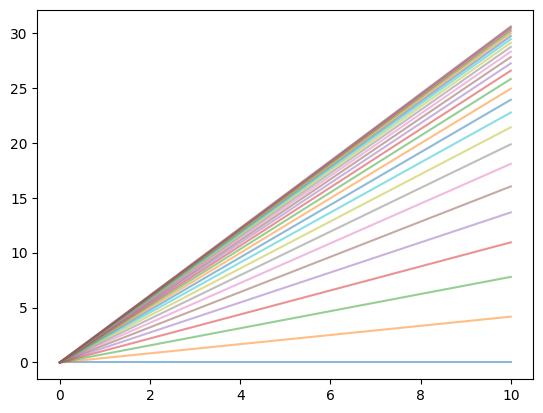

In [37]:
print(f"{'Step':<5} {'w':>8} {'Loss':>12} {'grad':>10}")
print('-' * 35)

for step in range(steps):
    y_pred = w * x_data
    loss = np.mean((y_pred - y_data) ** 2)
    grad = np.mean(2 * x_data * (y_pred - y_data))

    print(f"{step:<5} {w:>8.4f} {loss:>12.4f} {grad:>10.4f}")

    w_history.append(w)
    loss_history.append(loss)

    if step % 2 == 0 or step == steps - 1:
        plt.plot(x_data, w * x_data, label=f'Step {step}, w={w:.2f}', alpha=0.5)

    w = w - lr * grad

Visualization of the function obtained for different values of w and corresponding loss

C:\Users\Acer\AppData\Local\Temp\ipykernel_21988\1386983353.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', bbox_to_anchor=(1, 1))


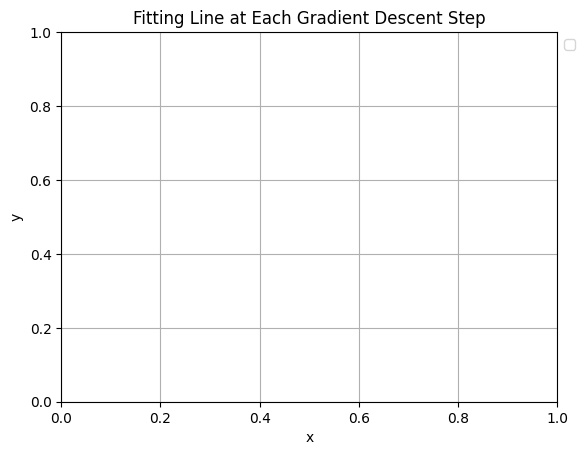

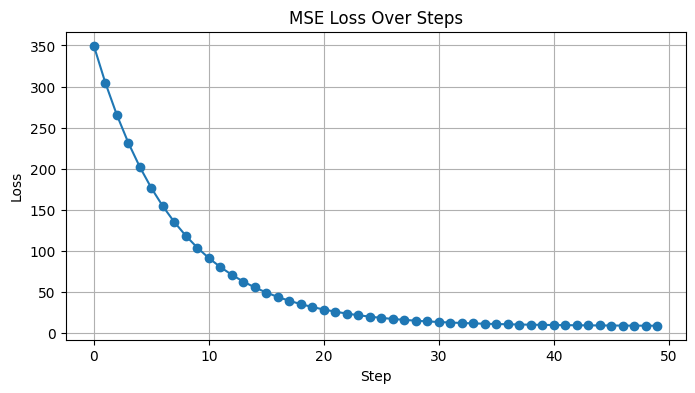

In [38]:
plt.title('Fitting Line at Each Gradient Descent Step')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o')
plt.title('MSE Loss Over Steps')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## EXERCISE 2: MNIST CLASSIFICATION

Import libraries

In [39]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Initialize hyperparameters and check GPU

In [40]:
BATCH_SIZE = 64
EPOCHS = 5
LR = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


Initialize the dataset and create train/test loaders

In [41]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Display one sample image from the training set

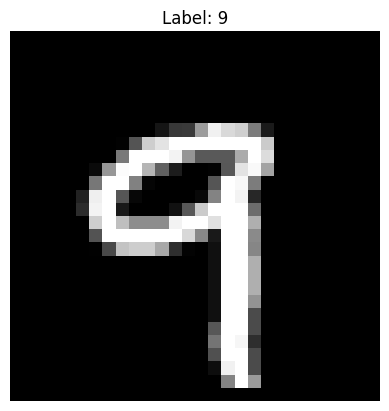

In [42]:
images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()

Define the MLP architecture

In [43]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

Define the CNN architecture

In [44]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

Define training and evaluation functions

In [45]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion=None):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if criterion is not None:
                total_loss += criterion(outputs, labels).item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader) if criterion is not None else None
    accuracy = correct / total
    return avg_loss, accuracy

Train the MLP model

In [46]:
mlp_model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LR)

mlp_train_losses = []
mlp_test_losses = []
mlp_test_accs = []

print('Training MLP...')
for epoch in range(EPOCHS):
    train_loss = train(mlp_model, train_loader, mlp_optimizer, criterion)
    test_loss, test_acc = evaluate(mlp_model, test_loader, criterion)

    mlp_train_losses.append(train_loss)
    mlp_test_losses.append(test_loss)
    mlp_test_accs.append(test_acc)

    print(f'Epoch {epoch + 1}: Loss={test_loss:.4f}, Acc={test_acc:.4f}')

Training MLP...
Epoch 1: Loss=0.1635, Acc=0.9496
Epoch 2: Loss=0.1241, Acc=0.9614
Epoch 3: Loss=0.0885, Acc=0.9732
Epoch 4: Loss=0.0849, Acc=0.9728
Epoch 5: Loss=0.0815, Acc=0.9751


Train the CNN model

In [21]:
cnn_model = CNN().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LR)

cnn_train_losses = []
cnn_test_losses = []
cnn_test_accs = []

print('Training CNN...')
for epoch in range(EPOCHS):
    train_loss = train(cnn_model, train_loader, cnn_optimizer, criterion)
    test_loss, test_acc = evaluate(cnn_model, test_loader, criterion)

    cnn_train_losses.append(train_loss)
    cnn_test_losses.append(test_loss)
    cnn_test_accs.append(test_acc)

    print(f'Epoch {epoch + 1}: Loss={test_loss:.4f}, Acc={test_acc:.4f}')

Training CNN...
Epoch 1: Loss=0.0490, Acc=0.9845
Epoch 2: Loss=0.0424, Acc=0.9858
Epoch 3: Loss=0.0358, Acc=0.9887
Epoch 4: Loss=0.0279, Acc=0.9909
Epoch 5: Loss=0.0282, Acc=0.9908


Compare MLP and CNN using loss and accuracy

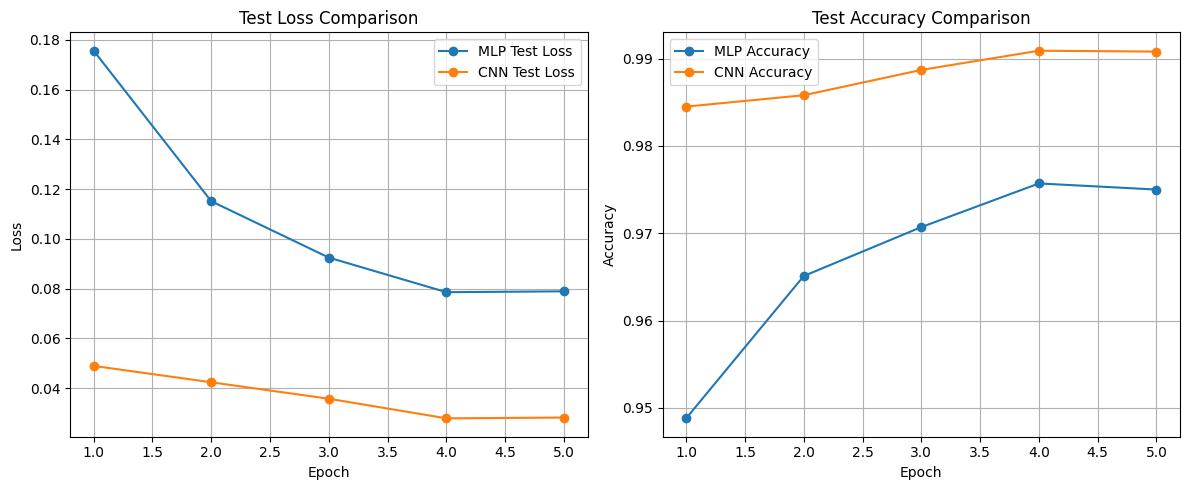

In [22]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, mlp_test_losses, marker='o', label='MLP Test Loss')
plt.plot(epochs, cnn_test_losses, marker='o', label='CNN Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Test Loss Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, mlp_test_accs, marker='o', label='MLP Accuracy')
plt.plot(epochs, cnn_test_accs, marker='o', label='CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Comments on model performance

- The MLP treats each image as a flat vector, so it ignores local spatial patterns.
- The CNN preserves the 2D structure of the image and usually achieves lower loss and higher accuracy.
- On MNIST, CNN is generally more suitable because convolution and pooling capture stroke features more effectively.

## EXERCISE 3: CIFAR-10 CLASSIFICATION

This exercise builds an image classification system for CIFAR-10 using three models: Basic CNN, VGG16, and ResNet18.

Import required libraries

In [47]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt

Initialize hyperparameters and check GPU

In [48]:
BATCH_SIZE = 128
EPOCHS = 10
LR = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


Initialize train and test datasets from the local CIFAR-10 archive in ./data

In [49]:
DATA_DIR = './data'

transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

classes = train_dataset.classes
print('Classes:', classes)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Inspect one sample from the training dataset

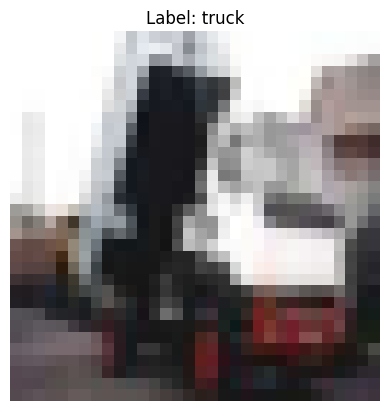

In [50]:
images, labels = next(iter(train_loader))

img = images[0] / 2 + 0.5
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.title(f'Label: {classes[labels[0].item()]}')
plt.axis('off')
plt.show()

Define training and evaluation functions

In [51]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct / total:.4f}'
        })

    avg_loss = total_loss / len(loader)
    avg_acc = correct / total
    return avg_loss, avg_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Eval', leave=False)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{correct / total:.4f}'
            })

    avg_loss = total_loss / len(loader)
    avg_acc = correct / total
    return avg_loss, avg_acc


def run_training(model, train_loader, test_loader, criterion, optimizer, device, epochs, model_name='Model'):
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    print(f'Training {model_name}...')
    for epoch in trange(epochs, desc=f'{model_name} Epoch'):
        train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        print(
            f'Epoch {epoch + 1}/{epochs} | '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}'
        )

    return train_losses, train_accs, test_losses, test_accs

Initialize the Basic CNN architecture

In [52]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Train the Basic CNN model

In [53]:
basiccnn_model = BasicCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(basiccnn_model.parameters(), lr=LR)

cnn_train_losses, cnn_train_accs, cnn_test_losses, cnn_test_accs = run_training(
    model=basiccnn_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_name='BasicCNN'
)

Training BasicCNN...


BasicCNN Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 1.5612 | Train Acc: 0.4302 | Test Loss: 1.2888 | Test Acc: 0.5296


...

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.6374 | Train Acc: 0.7798 | Test Loss: 0.6665 | Test Acc: 0.7705


Train:   0%|          | 0/391 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.6035 | Train Acc: 0.7913 | Test Loss: 0.6426 | Test Acc: 0.7765


Initialize VGG16 and train

In [56]:
vgg_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
vgg_model.classifier[6] = nn.Linear(vgg_model.classifier[6].in_features, 10)
vgg_model = vgg_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.parameters(), lr=LR)

vgg_train_losses, vgg_train_accs, vgg_test_losses, vgg_test_accs = run_training(
    model=vgg_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=3,
    model_name='VGG16'
)

Training VGG16...


VGG16 Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 1.6993 | Train Acc: 0.3156 | Test Loss: 1.2668 | Test Acc: 0.4936


...

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 0.9977 | Train Acc: 0.6450 | Test Loss: 0.8779 | Test Acc: 0.7105


Train:   0%|          | 0/391 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.7330 | Train Acc: 0.7641 | Test Loss: 0.7629 | Test Acc: 0.7479


Initialize ResNet18 and train

In [58]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=LR)

resnet_train_losses, resnet_train_accs, resnet_test_losses, resnet_test_accs = run_training(
    model=resnet_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=3,
    model_name='ResNet18'
)

Training ResNet18...


ResNet18 Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 0.8904 | Train Acc: 0.6987 | Test Loss: 0.7473 | Test Acc: 0.7492


...

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 0.6088 | Train Acc: 0.7947 | Test Loss: 0.6023 | Test Acc: 0.7963


Train:   0%|          | 0/391 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.4987 | Train Acc: 0.8304 | Test Loss: 0.5808 | Test Acc: 0.8038


Visualize test accuracy after each epoch

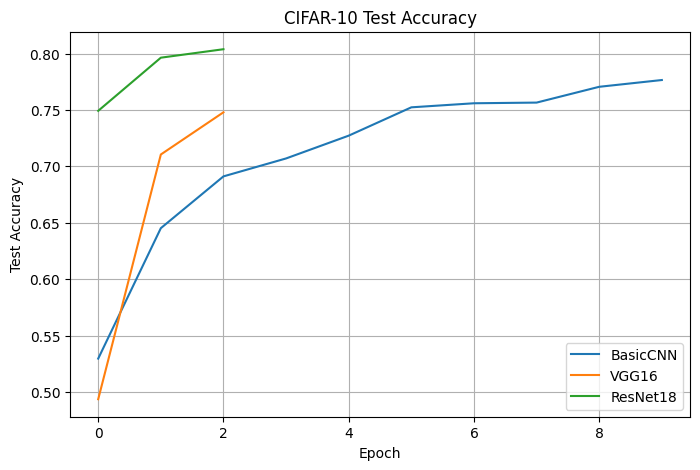

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_test_accs, label='BasicCNN')
plt.plot(vgg_test_accs, label='VGG16')
plt.plot(resnet_test_accs, label='ResNet18')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('CIFAR-10 Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

The chart shows the test accuracy comparison of three models on the CIFAR-10 dataset: BasicCNN, VGG16, and ResNet18.

Overall, ResNet18 achieves the best performance among the three models. Its test accuracy starts at around 0.75 and quickly increases to more than 0.80 after only a few epochs. This indicates that ResNet18 learns faster and extracts image features more effectively. The residual connections in ResNet help the model train more efficiently and improve classification performance.

VGG16 also improves quickly during training. Its accuracy increases from about 0.54 to approximately 0.75 after 3 epochs. Although VGG16 performs better than BasicCNN in the early epochs, it is trained for fewer epochs, so its final accuracy is lower than ResNet18 and slightly lower than BasicCNN at the end of training.

BasicCNN starts with the lowest accuracy but improves steadily over 10 epochs. Its final test accuracy reaches around 0.78. This shows that the custom CNN can learn useful features from CIFAR-10, but its performance is limited compared to deeper pretrained architectures.

In conclusion, ResNet18 gives the best result in this experiment, followed by BasicCNN and VGG16. Pretrained deep models such as ResNet18 and VGG16 generally perform better because they have stronger feature extraction ability. However, ResNet18 is more effective than VGG16 in this experiment because it achieves higher accuracy with fewer epochs.